In [1]:
import fitsio as fio
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from pycorr import (
    TwoPointCorrelationFunction, TwoPointEstimator, NaturalTwoPointEstimator, utils, setup_logging
)

In [2]:
ROOT = Path('./crosscorr/run3/')
TARGET = Path('ELGnotqso')

In [ ]:
def get_file(b1, b2, moc):
    """
    Get the file name for given redshift bins and MOC.
    """
    DIR = ROOT / TARGET 
    return f'{DIR}/{TARGET}__b1x{b1}_moc{moc}.npy'

def get_bins(name):
    return np.loadtxt(f'{ROOT}/bins/bins_{name}.txt', dtype=float)

In [12]:
result = TwoPointCorrelationFunction.load(get_file(1, 1, 0))

[0.3 0.6 0.9 1.2 1.5 1.8]


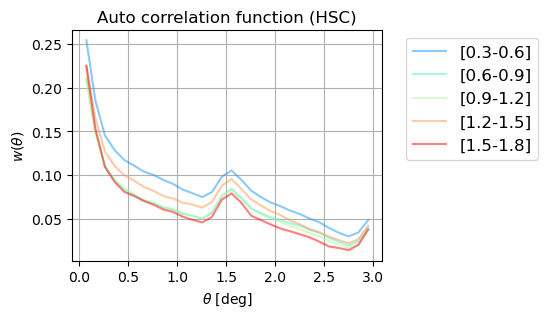

In [15]:
bhsc = np.arange(0.3, 2.1, 0.3)
print(bhsc)
cmap = plt.get_cmap('rainbow')
plt.figure(figsize=(4, 3))
ax = plt.gca()
for j in range(0,1):
    for i in range(1, len(bhsc)):
        result = TwoPointCorrelationFunction.load(get_file(i, 0, j))
        ls = '-' 
        if j == 1:
            ls = '--'
        if j == 2:
            ls = ':'
        ax.plot(
            result.sep, 
            result.corr, 
            alpha=0.5,
            linestyle=ls,
            label=f'[{bhsc[i-1]:.1f}-{bhsc[i]:.1f}]',
            color=cmap(i/(len(bhsc)-1)),
            )

ax.set_xlabel(r'$\theta$ [deg]')
ax.set_ylabel(r'$w(\theta)$')
ax.grid(True)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
ax.set_title(f'Auto correlation function ({TARGET})', fontsize=12)

#ax.set_yscale('log')
plt.show()

In [16]:
table = fio.FITS(Path(
                    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
                    ))

In [18]:
pz = table[1]['dnnz_photoz_best'].read()

Text(0.5, 1.0, 'Photo-z distribution (HSC)')

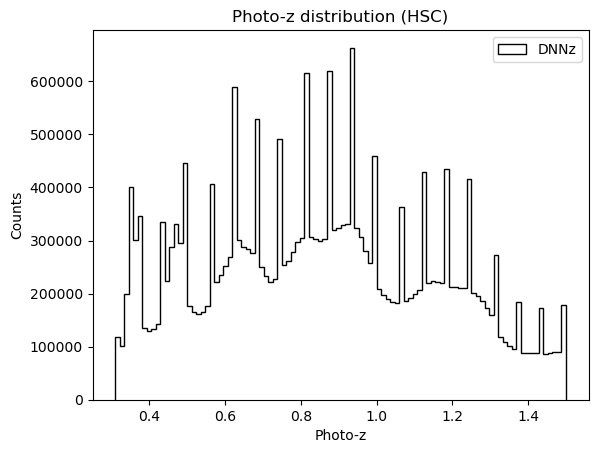

In [19]:
plt.hist(pz, bins=100, histtype='step', color='k', lw=2, label='DNNz')
plt.xlabel('Photo-z')
plt.ylabel('Counts')
plt.legend()
plt.title('Photo-z distribution (HSC)')

In [ ]:
import fitsio as fio
import os

os.listdir('/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/')

In [82]:
tbl = fio.FITS(
    '/global/cfs/projectdirs/desi/survey/catalogs/Y3/LSS/loa-v1/LSScats/v1.1/nonKP/ELGnotqso_clustering.dat.fits'
    )

In [83]:
sz = tbl[1]['Z'].read()

In [87]:
min(sz), max(sz)

(0.8000000181478555, 1.5999997110135349)

In [ ]:
len(sz)
bins_bgs = np.arange(0, 0.6, 0.1) # 0 < z < 0.6
bins_lrg = np.arange(0.4, 1.2, 0.1) # 0.4 < z < 1
bhsc = np.arange(0.8, 1.7, 0.1) # 0.6 < z < 1.6 => 0.8 < z < 1.6 in redshift distribution
bins_qso = np.arange(0.8, 3.4, 0.1) # 0.9 < z < 2.1

Text(0.5, 1.0, 'ELGnotqso redshift distribution')

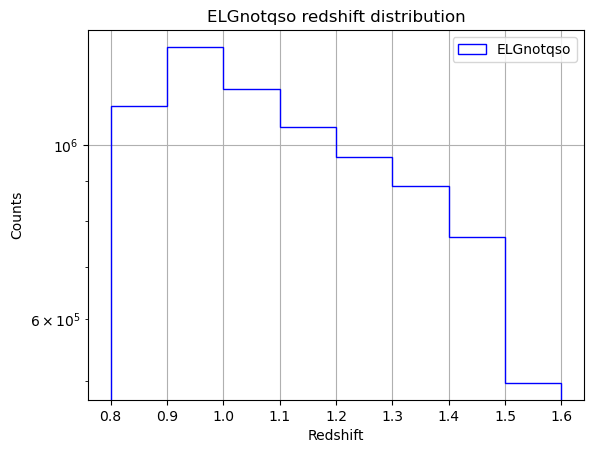

In [ ]:
plt.hist(sz, bins=bhsc, histtype='step', color='blue', lw=2, label='ELGnotqso')
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('ELGnotqso redshift distribution')

In [20]:
cat = fio.FITS(
    '/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/data/hsc/cat/hscy3_cat.fits'
    )
cat[1].get_colnames()
pz = cat[1]['dnnz_photoz_best'].read()

1.5 0.31


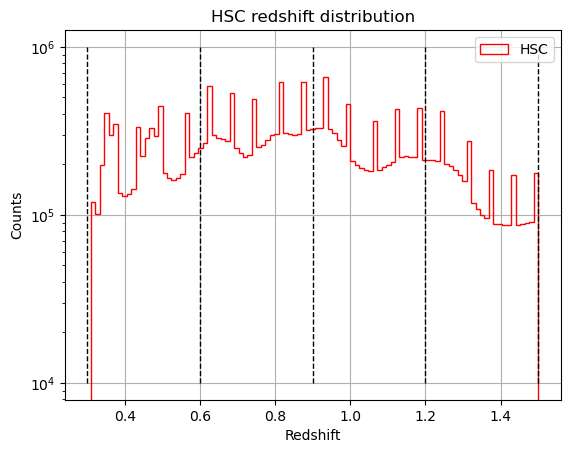

In [26]:
#bins_hsc = np.arange(0.3, 1.8, 0.3)
plt.hist(pz, bins=100, histtype='step', color='red', lw=2, label='HSC')
plt.vlines(
    [0.3, 0.6, 0.9, 1.2, 1.5], 
    ymin=1e4, ymax=1e6,
    color='black', linestyle='--', lw=1
    )
plt.legend()
plt.yscale('log')
plt.ylabel('Counts')
plt.xlabel('Redshift')
plt.grid()
plt.title('HSC redshift distribution')
print(max(pz), min(pz))

In [27]:
np.digitize(pz, bins_hsc)

array([2, 3, 1, ..., 4, 2, 3])

In [11]:
result.edges

[array([0.01      , 0.10966667, 0.20933333, 0.309     , 0.40866667,
        0.50833333, 0.608     , 0.70766667, 0.80733333, 0.907     ,
        1.00666667, 1.10633333, 1.206     , 1.30566667, 1.40533333,
        1.505     , 1.60466667, 1.70433333, 1.804     , 1.90366667,
        2.00333333, 2.103     , 2.20266667, 2.30233333, 2.402     ,
        2.50166667, 2.60133333, 2.701     , 2.80066667, 2.90033333,
        3.        ])]

In [4]:
import numpy as np
np.logspace(np.log10(0.001), np.log10(3), 71)

array([1.00000000e-03, 1.12117437e-03, 1.25703197e-03, 1.40935202e-03,
       1.58012936e-03, 1.77160054e-03, 1.98627312e-03, 2.22695851e-03,
       2.49680880e-03, 2.79935803e-03, 3.13856847e-03, 3.51888253e-03,
       3.94528089e-03, 4.42334782e-03, 4.95934420e-03, 5.56028960e-03,
       6.23405418e-03, 6.98946176e-03, 7.83640538e-03, 8.78597685e-03,
       9.85061205e-03, 1.10442538e-02, 1.23825342e-02, 1.38829800e-02,
       1.55652413e-02, 1.74513496e-02, 1.95660059e-02, 2.19369043e-02,
       2.45950949e-02, 2.75753900e-02, 3.09168204e-02, 3.46631466e-02,
       3.88634315e-02, 4.35726833e-02, 4.88525757e-02, 5.47722558e-02,
       6.14092493e-02, 6.88504763e-02, 7.71933893e-02, 8.65472495e-02,
       9.70345578e-02, 1.08792659e-01, 1.21975541e-01, 1.36755850e-01,
       1.53327154e-01, 1.71906475e-01, 1.92737134e-01, 2.16091934e-01,
       2.42276738e-01, 2.71634469e-01, 3.04549604e-01, 3.41453210e-01,
       3.82828587e-01, 4.29217600e-01, 4.81227771e-01, 5.39540243e-01,
      